# Введение в GCNN. Message passing framework

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. Курс "Машинное обучение на графах", Лекции 4-5 "Графовые нейронные сети"
* Документация:
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.triangles.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.distance_measures.eccentricity.html#networkx.algorithms.distance_measures.eccentricity
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.eigenvector_centrality.html

* Дополнительные источники:
    * https://tkipf.github.io/graph-convolutional-networks/

## Вопросы для совместного обсуждения

1\. Обсудите общие принципы организации вычислений в MPF и его использование для построения графовых сверточных нейронных сетей. 

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Загрузите граф из файла `karate.graphml`. Визуализируйте граф, раскрасив в цвета классов (атрибут `label` у узлов). 

Получите невзвешенную матрицу смежности $\mathbf{A}$ в виде тензора `torch` и тензор меток для каждого узла. Выведите полученные тензоры на экран.

- [ ] Проверено на семинаре

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import torch
import numpy as np

In [2]:
file_path = '/Users/andreyserba/Desktop/графы/karate.graphml' 

G = nx.read_graphml(file_path)


In [3]:
labels_dict = nx.get_node_attributes(G, 'label')

labels_dict = {node: G.degree(node) % 2 for node in G.nodes()} 

In [4]:
unique_labels = sorted(list(set(labels_dict.values())))
label_map = {label: i for i, label in enumerate(unique_labels)}
numeric_labels = [label_map[labels_dict[node]] for node in G.nodes()]

In [5]:
colors = plt.cm.get_cmap('viridis', len(unique_labels)) 
node_colors = [colors(label) for label in numeric_labels]

/var/folders/l6/hgcfppld1r9b94p4h4m34fgh0000gn/T/ipykernel_83669/2751490706.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_labels))


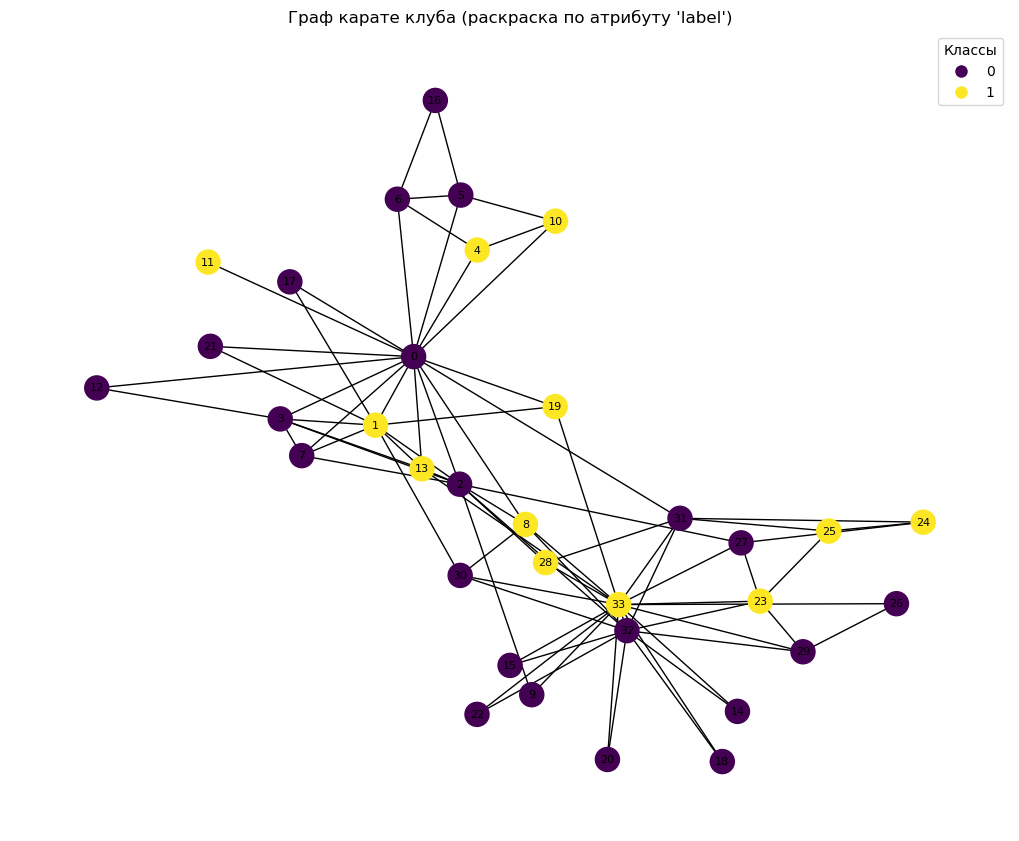

In [6]:
pos = nx.spring_layout(G, seed=42) 

plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=300, font_size=8)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors(i), markersize=10) for i in range(len(unique_labels))]

plt.legend(handles, unique_labels, title="Классы")
plt.title("Граф карате клуба (раскраска по атрибуту 'label')")
plt.show()

node_list = list(G.nodes())

adj_matrix_np = nx.to_numpy_array(G, nodelist=node_list, weight=None)

adj_tensor = torch.from_numpy(adj_matrix_np).float()

labels_np = np.array([label_map[labels_dict[node]] for node in node_list])

labels_tensor = torch.from_numpy(labels_np).long()

In [7]:
print("\nНевзвешенная матрица смежности (torch.Tensor):")
print(adj_tensor)
print("\nМетки узлов (torch.Tensor):")
print(labels_tensor)
print("\nРазмерность матрицы смежности:", adj_tensor.shape)
print("Размерность тензора меток:", labels_tensor.shape)


Невзвешенная матрица смежности (torch.Tensor):
tensor([[0., 1., 1.,  ..., 1., 0., 0.],
        [1., 0., 1.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 0., 0.,  ..., 0., 1., 1.],
        [0., 0., 1.,  ..., 1., 0., 1.],
        [0., 0., 0.,  ..., 1., 1., 0.]])

Метки узлов (torch.Tensor):
tensor([0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
        1, 1, 0, 0, 1, 0, 0, 0, 0, 1])

Размерность матрицы смежности: torch.Size([34, 34])
Размерность тензора меток: torch.Size([34])


<p class="task" id="2"></p>

2\. Найдите стохастическую матрицу $\hat{\mathbf{A}}$. 

$$\hat{\mathbf{A}} =\mathbf{D}^{-1}\mathbf{A}$$


Сгенерируйте тензор $\mathbf{X}$ размера `Nx5` с признаками узлов, используя `torch.rand`. Выполните один шаг рассылки сообщений при помощи матричного умножения.

$$\hat{\mathbf{X}} =\hat{\mathbf{A}}\mathbf{X}$$

Выполните этот же шаг рассылки сообщений, явно проитерировавшись по узлам графа и усреднив атрибуты соседей. Сравните два полученных тензора и покажите, что они равны.
 
- [ ] Проверено на семинаре

In [8]:
# --- 1. Получение невзвешенной бинарной матрицы A ---
A = (adj_tensor > 0).float()
print("\nБинарная матрица смежности A:")
print(A)


Бинарная матрица смежности A:
tensor([[0., 1., 1.,  ..., 1., 0., 0.],
        [1., 0., 1.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 0., 0.,  ..., 0., 1., 1.],
        [0., 0., 1.,  ..., 1., 0., 1.],
        [0., 0., 0.,  ..., 1., 1., 0.]])


In [9]:

N = A.shape[0] 

# --- 2. Расчет матрицы степеней D и обратной D^-1 ---
degrees = A.sum(dim=1) # Сумма по строкам дает степени узлов

degrees[degrees == 0] = 1 
D_inv = torch.diag(1.0 / degrees)
print("\nОбратная диагональная матрица степеней D^-1:")
print(D_inv)


Обратная диагональная матрица степеней D^-1:
tensor([[0.0625, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.1111, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.1000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.1667, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0833, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0588]])


In [10]:
# --- 3. Расчет стохастической матрицы A_hat ---
A_hat = torch.matmul(D_inv, A)
print("\nСтохастическая матрица A_hat = D^-1 * A:")
print(A_hat)
print("Суммы по строкам A_hat (должны быть 1 или 0):", A_hat.sum(dim=1))


Стохастическая матрица A_hat = D^-1 * A:
tensor([[0.0000, 0.0625, 0.0625,  ..., 0.0625, 0.0000, 0.0000],
        [0.1111, 0.0000, 0.1111,  ..., 0.0000, 0.0000, 0.0000],
        [0.1000, 0.1000, 0.0000,  ..., 0.0000, 0.1000, 0.0000],
        ...,
        [0.1667, 0.0000, 0.0000,  ..., 0.0000, 0.1667, 0.1667],
        [0.0000, 0.0000, 0.0833,  ..., 0.0833, 0.0000, 0.0833],
        [0.0000, 0.0000, 0.0000,  ..., 0.0588, 0.0588, 0.0000]])
Суммы по строкам A_hat (должны быть 1 или 0): tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


In [11]:
# --- 4. Генерация признаков узлов X ---
num_features = 5
X = torch.rand(N, num_features)
print(f"\nСгенерированный тензор признаков X (размер {N}x{num_features}):")
print(X[:5]) 


Сгенерированный тензор признаков X (размер 34x5):
tensor([[0.5765, 0.1800, 0.2264, 0.3440, 0.1052],
        [0.7029, 0.7609, 0.4160, 0.4499, 0.8620],
        [0.3323, 0.8460, 0.2717, 0.2624, 0.9196],
        [0.5552, 0.1531, 0.0698, 0.7093, 0.3230],
        [0.4862, 0.4170, 0.3049, 0.9396, 0.7731]])


In [12]:
# --- 5. Рассылка сообщений через матричное умножение ---
X_hat_matrix = torch.matmul(A_hat, X)
print("\nРезультат рассылки сообщений (матричное умножение) X_hat_matrix:")
print(X_hat_matrix[:5]) 


Результат рассылки сообщений (матричное умножение) X_hat_matrix:
tensor([[0.4406, 0.4939, 0.5346, 0.5152, 0.6305],
        [0.4493, 0.4261, 0.5292, 0.5044, 0.4461],
        [0.4885, 0.4430, 0.4596, 0.4775, 0.5582],
        [0.4737, 0.6468, 0.3983, 0.3115, 0.6283],
        [0.6255, 0.4123, 0.3220, 0.4267, 0.5160]])


In [13]:
# --- 6. Рассылка сообщений через итерацию по узлам ---
X_hat_iter = torch.zeros_like(X) 
for i in range(N):
    # Находим соседей узла i (индексы j, где A[i, j] == 1)
    neighbor_indices = A[i].nonzero(as_tuple=True)[0]
    # Получаем степени (можно взять из degrees, но так тоже можно)
    degree_i = len(neighbor_indices) # Равносильно degrees[i], если мы не меняли его на 1

    if degree_i > 0:
        # Собираем признаки соседей
        neighbor_features = X[neighbor_indices]
        # Усредняем признаки соседей
        X_hat_iter[i] = neighbor_features.sum(dim=0) / degree_i

print("\nРезультат рассылки сообщений (явная итерация) X_hat_iter:")
print(X_hat_iter[:5]) 


Результат рассылки сообщений (явная итерация) X_hat_iter:
tensor([[0.4406, 0.4939, 0.5346, 0.5152, 0.6305],
        [0.4493, 0.4261, 0.5292, 0.5044, 0.4461],
        [0.4885, 0.4430, 0.4596, 0.4775, 0.5582],
        [0.4737, 0.6468, 0.3983, 0.3115, 0.6283],
        [0.6255, 0.4123, 0.3220, 0.4267, 0.5160]])


In [14]:
# --- 7. Сравнение результатов ---
are_equal = torch.allclose(X_hat_matrix, X_hat_iter)
print(f"\nТензоры X_hat_matrix и X_hat_iter равны (с учетом точности float): {are_equal}")

# Дополнительная проверка разницы
difference = torch.abs(X_hat_matrix - X_hat_iter)
print("Максимальная абсолютная разница:", difference.max().item())


Тензоры X_hat_matrix и X_hat_iter равны (с учетом точности float): True
Максимальная абсолютная разница: 5.960464477539063e-08


<p class="task" id="3"></p>

3\. Опишите слой `GCNLayer` графовой сверточной нейронной сети. Создайте слой с `n_outputs=3` и пропустите через этот слой матрицу смежности графа и тензор признаков  $\mathbf{X} = \mathbf{E}$. Выведите форму полученного тензора на экран.

- [ ] Проверено на семинаре

In [15]:
import torch
import torch.nn as nn
from typing import Callable

In [ ]:

# Исходная бинарная матрица смежности
A = adj_tensor
N = A.shape[0] # Количество узлов


class GCNLayer(nn.Module):

    def __init__(self, n_inputs: int, n_outputs: int, activation: Callable | None = None) -> None:
        super().__init__()

        # self.W - веса слоя (обучаемый параметр)
        W = torch.empty(n_inputs, n_outputs, dtype=torch.float32)
        nn.init.xavier_uniform_(W) # Инициализация Xavier для весов
        self.W = nn.Parameter(W, requires_grad=True)

        # self.activation - функция активации, применяется после агрегации и трансформации
        self.activation = activation

    def normalize_matrix(self, A: torch.Tensor) -> torch.Tensor:

        N = A.shape[0]
        # 1. Добавляем петли: Ã = A + I
        I = torch.eye(N, dtype=A.dtype, device=A.device)
        A_tilde = A + I

        # 2. Считаем степени узлов для Ã: D̃_ii = Σ_j Ã_ij
        degrees_tilde = A_tilde.sum(dim=1)

        # 3. Вычисляем D̃^(-1/2)
        D_inv_sqrt = torch.pow(degrees_tilde, -0.5)
        # Заменяем бесконечные значения (возникающие из нулевых степеней) на 0
        D_inv_sqrt[torch.isinf(D_inv_sqrt)] = 0.0

        # 4. Создаем диагональную матрицу из D̃^(-1/2)
        D_inv_sqrt_diag = torch.diag(D_inv_sqrt)

        # 5. Вычисляем нормализованную матрицу: Â = D̃^(-1/2) * Ã * D̃^(-1/2)
        A_hat = D_inv_sqrt_diag @ A_tilde @ D_inv_sqrt_diag

        return A_hat


    def forward(self, A: torch.Tensor, X: torch.Tensor) -> torch.Tensor:

        # 1. Нормализуем матрицу смежности
        A_hat = self.normalize_matrix(A)

        # 2. Агрегируем информацию от соседей (включая себя): Â * X
        support = torch.matmul(A_hat, X) # или A_hat @ X

        # 3. Применяем линейное преобразование: (Â * X) * W
        output = torch.matmul(support, self.W) # или support @ self.W

        # 4. Применяем функцию активации, если она задана
        if self.activation is not None:
            output = self.activation(output)

        return output

n_outputs = 3


n_inputs = N
X_identity = torch.eye(N, dtype=torch.float32)
print(f"\nРазмер входной матрицы признаков X=E: {X_identity.shape}")

gcn_layer = GCNLayer(n_inputs=n_inputs, n_outputs=n_outputs, activation=None) # Без активации
print(f"Создан слой GCNLayer с n_inputs={n_inputs}, n_outputs={n_outputs}")

output_tensor = gcn_layer(A, X_identity)

print(f"\nФорма выходного тензора после прохода через GCNLayer: {output_tensor.shape}")


Размер входной матрицы признаков X=E: torch.Size([34, 34])
Создан слой GCNLayer с n_inputs=34, n_outputs=3

Форма выходного тензора после прохода через GCNLayer: torch.Size([34, 3])


<p class="task" id="4"></p>

4\. Используя графовую сверточную нейронную сеть, решите задачу классификации узлов. Создайте модель, состоящую из двух последовательно идущих слоев `GCNLayer`. Первый слой имеет 2 нейрона и гиперболический тангенс в качестве функции активации. Количество нейронов во втором слое определяется количеством классов в задаче. Настройте модель (в качестве признаков узлов используйте единичную матрицу $\mathbf{X} = \mathbf{E}$). 

После завершения процесса обучения пропустите данные через первый слой и визуализируйте граф, используя полученные векторные представления в качестве координат. Раскрасьте узлы в цвет соответствующих классов.

- [ ] Проверено на семинаре

In [17]:
import torch.optim as optim
import torch.nn.functional as F

In [18]:
# --- Переиспользуем класс GCNLayer из Задания 3 ---
class GCNLayer(nn.Module):
    """
    Слой графовой сверточной сети (GCN).
    Выполняет операцию: H' = σ(Â * H * W), где Â - нормализованная матрица смежности с петлями.
    """
    def __init__(self, n_inputs: int, n_outputs: int, activation: Callable | None = None) -> None:
        super().__init__()
        W = torch.empty(n_inputs, n_outputs, dtype=torch.float32)
        nn.init.xavier_uniform_(W)
        self.W = nn.Parameter(W, requires_grad=True)
        self.activation = activation

    def normalize_matrix(self, A: torch.Tensor) -> torch.Tensor:
        """Нормализует исходную матрицу смежности A: Â = D̃^(-1/2) * Ã * D̃^(-1/2), где Ã = A + I."""
        N = A.shape[0]
        I = torch.eye(N, dtype=A.dtype, device=A.device)
        A_tilde = A + I
        degrees_tilde = A_tilde.sum(dim=1)
        D_inv_sqrt = torch.pow(degrees_tilde, -0.5)
        D_inv_sqrt[torch.isinf(D_inv_sqrt)] = 0.0
        D_inv_sqrt_diag = torch.diag(D_inv_sqrt)
        A_hat = D_inv_sqrt_diag @ A_tilde @ D_inv_sqrt_diag
        return A_hat

    def forward(self, A: torch.Tensor, X: torch.Tensor) -> torch.Tensor:
        """Прямой проход слоя GCN."""
        A_hat = self.normalize_matrix(A)
        support = torch.matmul(A_hat, X) # A_hat @ X
        output = torch.matmul(support, self.W) # support @ W
        if self.activation is not None:
            output = self.activation(output)
        return output

In [19]:
# --- Класс модели GCN ---
class GCN(nn.Module):
    def __init__(self, n_features: int, n_hidden: int, n_classes: int):
        super().__init__()
        self.gcn1 = GCNLayer(n_features, n_hidden, activation=torch.tanh)
        self.gcn2 = GCNLayer(n_hidden, n_classes, activation=None)

    def forward(self, A: torch.Tensor, X: torch.Tensor) -> torch.Tensor:
        h1 = self.gcn1(A, X)
        output = self.gcn2(A, h1)
        return output

    def get_embeddings(self, A: torch.Tensor, X: torch.Tensor) -> torch.Tensor:
        return self.gcn1(A, X)

In [20]:
# --- Параметры ---
N = adj_tensor.shape[0] 
n_features = N          
n_hidden = 2      
n_classes = labels_tensor.max().item() + 1 
learning_rate = 0.001
epochs = 300

In [21]:
# Создаем единичную матрицу признаков X = E
X_identity = torch.eye(N, dtype=torch.float32)

A = adj_tensor

# --- Создание модели, функции потерь и оптимизатора ---
model = GCN(n_features=n_features, n_hidden=n_hidden, n_classes=n_classes)
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=learning_rate) 

In [22]:
# --- Цикл обучения ---
model.train() 
for epoch in range(epochs):
    optimizer.zero_grad()      
    outputs = model(A, X_identity) 
    loss = criterion(outputs, labels_tensor) 
    loss.backward()            
    optimizer.step()           

    if (epoch + 1) % 20 == 0:
        _, predicted = torch.max(outputs, 1)
        correct = (predicted == labels_tensor).sum().item()
        accuracy = correct / N
        print(f'Эпоха [{epoch+1}/{epochs}], Потери: {loss.item():.4f}, Точность: {accuracy:.4f}')

print("Обучение завершено.")

Эпоха [20/300], Потери: 0.6938, Точность: 0.5000
Эпоха [40/300], Потери: 0.6849, Точность: 0.5294
Эпоха [60/300], Потери: 0.6767, Точность: 0.5000
Эпоха [80/300], Потери: 0.6687, Точность: 0.5882
Эпоха [100/300], Потери: 0.6608, Точность: 0.6471
Эпоха [120/300], Потери: 0.6529, Точность: 0.6471
Эпоха [140/300], Потери: 0.6452, Точность: 0.6765
Эпоха [160/300], Потери: 0.6376, Точность: 0.7059
Эпоха [180/300], Потери: 0.6302, Точность: 0.7353
Эпоха [200/300], Потери: 0.6229, Точность: 0.7353
Эпоха [220/300], Потери: 0.6158, Точность: 0.7353
Эпоха [240/300], Потери: 0.6088, Точность: 0.7353
Эпоха [260/300], Потери: 0.6021, Точность: 0.7059
Эпоха [280/300], Потери: 0.5954, Точность: 0.7059
Эпоха [300/300], Потери: 0.5889, Точность: 0.7059
Обучение завершено.


/var/folders/l6/hgcfppld1r9b94p4h4m34fgh0000gn/T/ipykernel_83669/1085388006.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_numeric_labels))


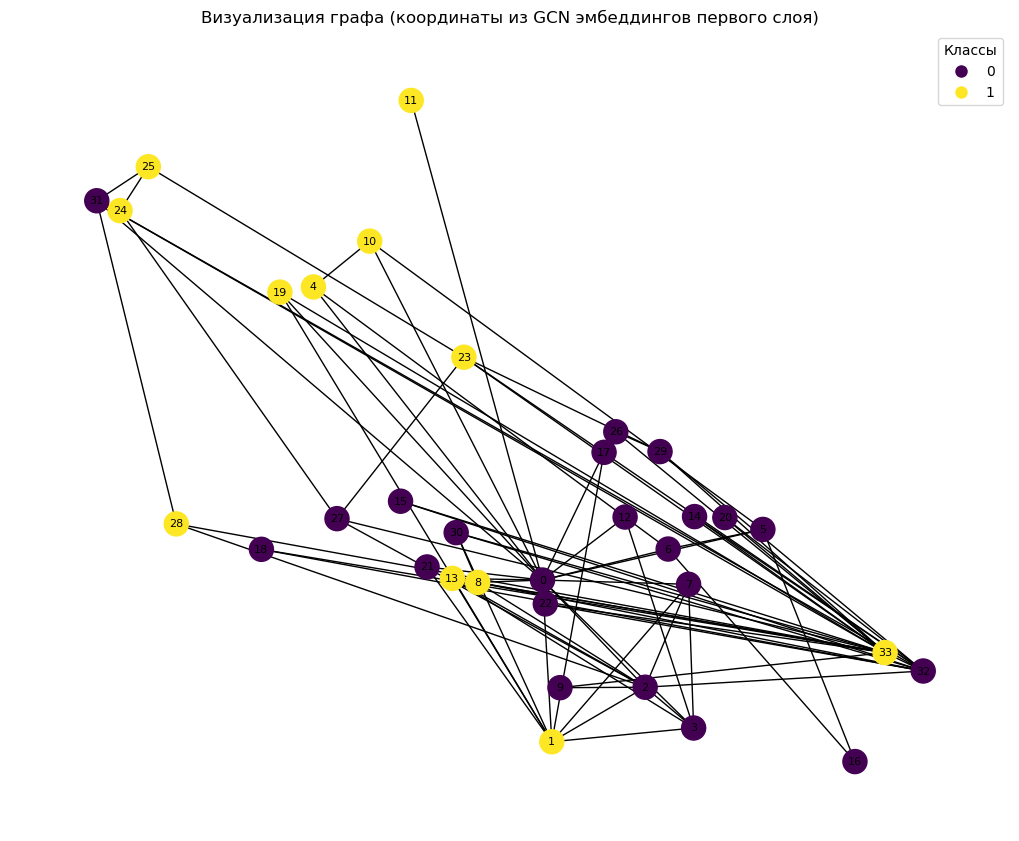

In [23]:
# --- Получение эмбеддингов и визуализация ---
model.eval() 
with torch.no_grad(): 
    embeddings_2d = model.get_embeddings(A, X_identity)

embeddings_np = embeddings_2d.numpy()

node_list = list(G.nodes()) 
pos_embeddings = {node: embeddings_np[i] for i, node in enumerate(node_list)}

numeric_labels = labels_tensor.numpy()
unique_numeric_labels = np.unique(numeric_labels)
colors = plt.cm.get_cmap('viridis', len(unique_numeric_labels))
node_colors = [colors(label) for label in numeric_labels]

plt.figure(figsize=(10, 8))
nx.draw(G, pos=pos_embeddings, with_labels=True, node_color=node_colors, node_size=300, font_size=8)

label_map_rev = {v: k for k, v in label_map.items()} 
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors(i), markersize=10)
           for i in range(len(unique_numeric_labels))]
plt.legend(handles, [label_map_rev[i] for i in unique_numeric_labels], title="Классы")

plt.title("Визуализация графа (координаты из GCN эмбеддингов первого слоя)")
plt.xlabel("Эмбеддинг, размерность 1")
plt.ylabel("Эмбеддинг, размерность 2")
plt.grid(True)
plt.show()

<p class="task" id="5"></p>

5\. Повторите решение предыдущей задачи, используя в качестве признаков $\mathbf{X}$ следующие характеристики узлов: 
* количество треугольников, в которые входит узел;
* степень узла;
* эксцентриситет узла;
* центральность по собственному вектору для узла.

Для ускорения процесса обучения стандартизуйте тензор признаков.


- [ ] Проверено на семинаре

In [24]:
from sklearn.preprocessing import StandardScaler # Можно использовать и torch для стандартизации

In [25]:
# --- Переиспользуем класс GCNLayer и GCN из Заданий 3 и 4 ---
class GCNLayer(nn.Module):
    """Слой графовой сверточной сети (GCN)."""
    def __init__(self, n_inputs: int, n_outputs: int, activation: Callable | None = None) -> None:
        super().__init__()
        W = torch.empty(n_inputs, n_outputs, dtype=torch.float32)
        nn.init.xavier_uniform_(W)
        self.W = nn.Parameter(W, requires_grad=True)
        self.activation = activation

    def normalize_matrix(self, A: torch.Tensor) -> torch.Tensor:
        """Нормализует исходную матрицу смежности A: Â = D̃^(-1/2) * Ã * D̃^(-1/2), где Ã = A + I."""
        N = A.shape[0]
        I = torch.eye(N, dtype=A.dtype, device=A.device)
        A_tilde = A + I
        degrees_tilde = A_tilde.sum(dim=1)
        D_inv_sqrt = torch.pow(degrees_tilde, -0.5)
        D_inv_sqrt[torch.isinf(D_inv_sqrt)] = 0.0
        D_inv_sqrt_diag = torch.diag(D_inv_sqrt)
        A_hat = D_inv_sqrt_diag @ A_tilde @ D_inv_sqrt_diag
        return A_hat

    def forward(self, A: torch.Tensor, X: torch.Tensor) -> torch.Tensor:
        """Прямой проход слоя GCN."""
        A_hat = self.normalize_matrix(A)
        support = torch.matmul(A_hat, X)
        output = torch.matmul(support, self.W)
        if self.activation is not None:
            output = self.activation(output)
        return output

In [26]:
class GCN(nn.Module):
    """Двухслойная GCN модель."""
    def __init__(self, n_features: int, n_hidden: int, n_classes: int):
        super().__init__()
        self.gcn1 = GCNLayer(n_features, n_hidden, activation=torch.tanh)
        self.gcn2 = GCNLayer(n_hidden, n_classes, activation=None)

    def forward(self, A: torch.Tensor, X: torch.Tensor) -> torch.Tensor:
        h1 = self.gcn1(A, X)
        output = self.gcn2(A, h1)
        return output

    def get_embeddings(self, A: torch.Tensor, X: torch.Tensor) -> torch.Tensor:
        """Получает выход первого слоя (эмбеддинги)."""
        return self.gcn1(A, X)

In [28]:
# --- Подготовка данных ---
file_path = '/Users/andreyserba/Desktop/графы/karate.graphml' 

G = nx.read_graphml(file_path)


In [29]:
node_list = list(G.nodes()) # Фиксированный порядок узлов
N = len(node_list)

# Получаем матрицу смежности (бинарную, float)
adj_matrix_np = nx.to_numpy_array(G, nodelist=node_list, weight=None)
A = torch.from_numpy((adj_matrix_np > 0)).float()

In [30]:
# Получаем метки (long)
try:
    labels_dict = nx.get_node_attributes(G, 'label')
    unique_labels = sorted(list(set(labels_dict.values())))
    label_map = {label: i for i, label in enumerate(unique_labels)}
    labels_np = np.array([label_map[labels_dict[node]] for node in node_list])
    labels_tensor = torch.from_numpy(labels_np).long()
    n_classes = len(unique_labels)
except KeyError:
    print("Ошибка: Атрибут 'label' не найден.")
    exit()

In [32]:
# 2. Вычисление признаков узлов
try:
    triangles = nx.triangles(G)
    degrees = dict(G.degree())
    # Эксцентриситет может быть долгим и требует связного графа
    if not nx.is_connected(G):
        print("Внимание: Граф не связный. Эксцентриситет может быть некорректным или вызвать ошибку.")
        # Можно вычислить по компонентам или присвоить дефолтное значение
        eccentricity = {node: N for node in node_list} # Пример: присвоить N как максимальное значение
    else:
        eccentricity = nx.eccentricity(G)
    eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000) # Увеличим max_iter на всякий случай
except Exception as e:
    print(f"Ошибка при вычислении признаков: {e}")
    exit()

In [33]:
# 3. Сборка матрицы признаков X
features_list = []
for node in node_list:
    node_features = [
        triangles.get(node, 0),
        degrees.get(node, 0),
        eccentricity.get(node, 0),
        eigenvector_centrality.get(node, 0.0)
    ]
    features_list.append(node_features)

X_features_np = np.array(features_list, dtype=np.float32)
X_features = torch.from_numpy(X_features_np)
n_features = X_features.shape[1] # Количество вычисленных признаков (должно быть 4)
print(f"Размер исходной матрицы признаков X: {X_features.shape}")

Размер исходной матрицы признаков X: torch.Size([34, 4])


In [34]:
# 4. Стандартизация признаков
# Способ 1: Используя torch
mean = X_features.mean(dim=0, keepdim=True)
std = X_features.std(dim=0, keepdim=True)

epsilon = 1e-8
X_standardized = (X_features - mean) / (std + epsilon)

print(f"Размер стандартизированной матрицы признаков X: {X_standardized.shape}")
print("Пример стандартизированных признаков (первые 5 строк):")
print(X_standardized[:5])

Размер стандартизированной матрицы признаков X: torch.Size([34, 4])
Пример стандартизированных признаков (первые 5 строк):
tensor([[ 2.9728,  2.9428, -1.4355,  2.3064],
        [ 1.7014,  1.1377, -1.4355,  1.3187],
        [ 1.4895,  1.3956, -1.4355,  1.8840],
        [ 1.2776,  0.3641, -1.4355,  0.7144],
        [-0.4176, -0.4096, -0.0410, -0.7771]])


In [35]:
# --- Параметры модели и обучения ---
n_hidden = 2           
learning_rate = 0.01
epochs = 300           

In [36]:
# --- Создание модели, функции потерь и оптимизатора ---
model = GCN(n_features=n_features, n_hidden=n_hidden, n_classes=n_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=5e-4) # Добавим L2 регуляризацию

In [37]:
# --- Цикл обучения ---
model.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    # Передаем стандартизированные признаки X_standardized
    outputs = model(A, X_standardized)
    loss = criterion(outputs, labels_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        _, predicted = torch.max(outputs, 1)
        correct = (predicted == labels_tensor).sum().item()
        accuracy = correct / N
        print(f'Эпоха [{epoch+1}/{epochs}], Потери: {loss.item():.4f}, Точность: {accuracy:.4f}')

print("Обучение завершено.")

Эпоха [20/300], Потери: 0.9975, Точность: 0.5294
Эпоха [40/300], Потери: 0.8610, Точность: 0.7059
Эпоха [60/300], Потери: 0.7623, Точность: 0.7647
Эпоха [80/300], Потери: 0.6866, Точность: 0.7647
Эпоха [100/300], Потери: 0.6251, Точность: 0.7941
Эпоха [120/300], Потери: 0.5729, Точность: 0.8235
Эпоха [140/300], Потери: 0.5280, Точность: 0.8235
Эпоха [160/300], Потери: 0.4890, Точность: 0.8235
Эпоха [180/300], Потери: 0.4549, Точность: 0.8824
Эпоха [200/300], Потери: 0.4248, Точность: 0.9118
Эпоха [220/300], Потери: 0.3981, Точность: 0.9118
Эпоха [240/300], Потери: 0.3746, Точность: 0.9118
Эпоха [260/300], Потери: 0.3540, Точность: 0.9118
Эпоха [280/300], Потери: 0.3362, Точность: 0.9118
Эпоха [300/300], Потери: 0.3210, Точность: 0.9118
Обучение завершено.


In [42]:
# --- Получение эмбеддингов и визуализация ---
model.eval()
with torch.no_grad():
    # Получаем эмбеддинги, используя стандартизированные признаки
    embeddings_2d = model.get_embeddings(A, X_standardized)

embeddings_np = embeddings_2d.numpy()

# Проверка формы эмбеддингов
print(f"Shape of embeddings_np before drawing: {embeddings_np.shape}")
if embeddings_np.shape != (N, 2):
     raise ValueError(f"Unexpected shape for embeddings: {embeddings_np.shape}. Expected ({N}, 2)")

# --- ПРЕОБРАЗУЕМ обратно в СЛОВАРЬ позиций ---
# Убедимся, что node_list актуален
if 'node_list' not in locals() or len(node_list) != N:
    node_list = list(G.nodes()) # Пересоздаем, если нужно
pos_embeddings_dict = {node: embeddings_np[i] for i, node in enumerate(node_list)}

Shape of embeddings_np before drawing: (34, 2)


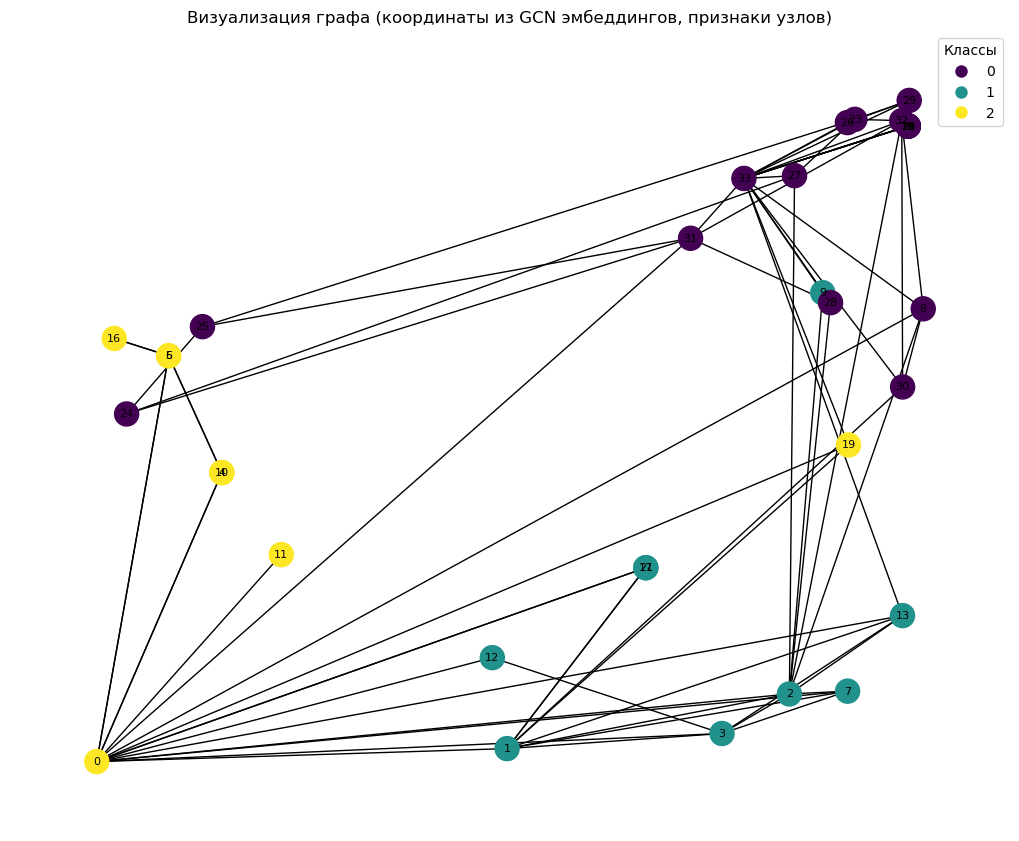

In [45]:
numeric_labels = labels_tensor.numpy()
unique_numeric_labels = np.unique(numeric_labels)

cmap = plt.colormaps.get_cmap('viridis')
num_colors = len(unique_numeric_labels)
colors_list = [cmap(i / (num_colors - 1)) if num_colors > 1 else cmap(0.5) for i in range(num_colors)]
node_colors = [colors_list[label] for label in numeric_labels]

# Визуализация
plt.figure(figsize=(10, 8))
nx.draw(G,
        pos=pos_embeddings_dict, # Используем словарь
        with_labels=True,
        node_color=node_colors,
        node_size=300,
        font_size=8)

# Создаем легенду
label_map_rev = {v: k for k, v in label_map.items()}
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors_list[i], markersize=10)
           for i in range(len(unique_numeric_labels))]
plt.legend(handles, [label_map_rev.get(i, f'Class {i}') for i in unique_numeric_labels], title="Классы")

plt.title("Визуализация графа (координаты из GCN эмбеддингов, признаки узлов)")
plt.xlabel("Эмбеддинг, размерность 1")
plt.ylabel("Эмбеддинг, размерность 2")
plt.grid(True)
plt.show()

6. По аналогии с заданием 3, реализуйте графовую свертку Чебышева и проверьте результат работы на аналогичных данных:
   - [cheb_conv статья](https://arxiv.org/pdf/1606.09375);
   - [cheb_conv torch_geometric](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.ChebConv.html#torch_geometric.nn.conv.ChebConv). 

В качестве параметра $K$ рассмотрите {${3,4}$}

In [46]:
from typing import Callable, Optional
from scipy.sparse.linalg import eigsh 

In [51]:
# Задаем n_outputs по аналогии с Заданием 3
n_outputs = 3

# --- Реализация слоя ChebConvLayer ---

class ChebConvLayer(nn.Module):

    def __init__(self, n_inputs: int, n_outputs: int, K: int,
                 activation: Optional[Callable] = None, lambda_max: Optional[float] = None):
        super().__init__()
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs
        self.K = K
        self.activation = activation
        self._lambda_max = lambda_max # Сохраняем для prepare_laplacian
        self.W = nn.Parameter(torch.empty(K, n_inputs, n_outputs, dtype=torch.float32))
        nn.init.xavier_uniform_(self.W) # Инициализация Ксавье

    def prepare_laplacian(self, A: torch.Tensor) -> torch.Tensor:

        N = A.shape[0]
        degrees = A.sum(dim=1)
        degrees[degrees == 0] = 1.0
        D_inv_sqrt = torch.pow(degrees, -0.5)
        D_inv_sqrt_diag = torch.diag(D_inv_sqrt)

        I = torch.eye(N, dtype=A.dtype, device=A.device)
        L_sym = I - D_inv_sqrt_diag @ A @ D_inv_sqrt_diag

        lambda_max = self._lambda_max if self._lambda_max is not None else 2.0

        L_scal = (2.0 / lambda_max) * L_sym - I
        return L_scal

    def forward(self, A: torch.Tensor, X: torch.Tensor) -> torch.Tensor:

        N = X.shape[0]
        L_scal = self.prepare_laplacian(A)

        Tx_0 = X
        cheb_polynomials = [Tx_0]

        if self.K > 1:
            Tx_1 = torch.matmul(L_scal, Tx_0) # L_scal @ Tx_0
            cheb_polynomials.append(Tx_1)

        for k in range(2, self.K):
            Tx_k = 2.0 * torch.matmul(L_scal, cheb_polynomials[-1]) - cheb_polynomials[-2]
            cheb_polynomials.append(Tx_k)

        # Альтернатива без einsum (возможно, понятнее):
        output = torch.zeros(N, self.n_outputs, dtype=X.dtype, device=X.device)
        for k in range(self.K):
            T_k_X = cheb_polynomials[k] # Результат T_k(L_scal) * X
            term_k = torch.matmul(T_k_X, self.W[k]) # T_k_X @ self.W[k] # (N, n_inputs) @ (n_inputs, n_outputs) -> (N, n_outputs)
            output = output + term_k

        # Применяем активацию
        if self.activation is not None:
            output = self.activation(output)

        return output


In [52]:
print("Проверка работы ChebConvLayer:")

for k_val in [3, 4]:
    print(f"\n--- K = {k_val} ---")
    # Создаем экземпляр слоя
    cheb_layer = ChebConvLayer(n_inputs=n_inputs, n_outputs=n_outputs, K=k_val, activation=None)
    print(f"Создан слой: {cheb_layer}")

    output_tensor = cheb_layer(A, X_identity)

    # Выводим форму полученного тензора
    print(f"Форма выходного тензора для K={k_val}: {output_tensor.shape}")
    print("Пример выходного тензора (первые 5 строк):")
    print(output_tensor[:5])

Проверка работы ChebConvLayer:

--- K = 3 ---
Создан слой: ChebConvLayer()
Форма выходного тензора для K=3: torch.Size([34, 3])
Пример выходного тензора (первые 5 строк):
tensor([[-0.2465,  0.3377, -0.0023],
        [ 0.1377, -0.1107, -0.1919],
        [-0.1179,  0.4657,  0.2584],
        [ 0.0331, -0.0628,  0.1036],
        [-0.0267,  0.0720, -0.0417]], grad_fn=<SliceBackward0>)

--- K = 4 ---
Создан слой: ChebConvLayer()
Форма выходного тензора для K=4: torch.Size([34, 3])
Пример выходного тензора (первые 5 строк):
tensor([[ 0.0291, -0.1839,  0.0773],
        [ 0.2007, -0.0095, -0.0499],
        [ 0.1519, -0.2883,  0.0848],
        [-0.4466,  0.0461,  0.3908],
        [-0.0148, -0.0153,  0.1890]], grad_fn=<SliceBackward0>)
